# 🧬 Chromosome Classification — MobileNetV2
## Notebook 4 of 5
**Estimated time on Kaggle P100:** ~~30 min
**After this notebook:** Download `mobilenetv2_best.keras` and `mobilenetv2_test_probs.npy`
from Output tab → upload to a new Kaggle Dataset → use in Notebook 6 (Ensemble)

## Cell 1 — Setup + Imports

In [1]:
# Cell 0A — Download dataset into Colab
import os
from google.colab import files

print("📁 Upload your kaggle.json file...")
uploaded = files.upload()

# Get whatever filename was uploaded (handles kaggle(1).json etc)
uploaded_name = list(uploaded.keys())[0]
print(f"Uploaded as: {uploaded_name}")

# Place in correct location regardless of filename
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded[uploaded_name])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ kaggle.json placed correctly")

# Install kaggle CLI
!pip install -q kaggle

# Check if dataset already downloaded to save time
if os.path.exists('/content/chromo_data/Data/single_chromosomes_object/JEPG'):
    print("✅ Dataset already exists — skipping download")
else:
    print("📥 Downloading dataset (~2-3 minutes)...")
    !kaggle datasets download \
        -d aliabedimadiseh/chromosome-image-dataset-karyotype \
        --path /content/chromo_data \
        --unzip -q
    print("✅ Download complete")

# Verify
img_dir = '/content/chromo_data/Data/single_chromosomes_object/JEPG'
if os.path.exists(img_dir):
    count = len(os.listdir(img_dir))
    print(f"✅ Images found: {count} (should be ~2986)")
else:
    print("❌ Image folder not found — check path")
    for root, dirs, files in os.walk('/content/chromo_data'):
        level = root.replace('/content/chromo_data','').count(os.sep)
        if level > 3: continue
        print('  '*level + os.path.basename(root) + '/')

📁 Upload your kaggle.json file...


Saving kaggle.json to kaggle (11).json
Uploaded as: kaggle (11).json
✅ kaggle.json placed correctly
✅ Dataset already exists — skipping download
✅ Images found: 2000 (should be ~2986)


In [2]:
# ── NEW CELL 0B: Verify GPU ──────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU active: {gpus[0].name}')
    print(f'   Make sure you selected GPU in Runtime → Change runtime type')
else:
    print('⚠️  NO GPU DETECTED')
    print('   Go to: Runtime → Change runtime type → Hardware accelerator → T4 GPU')
    print('   Then run this cell again')

tf.keras.mixed_precision.set_global_policy('float32')
print('✅ Precision: float32')

✅ GPU active: /physical_device:GPU:0
   Make sure you selected GPU in Runtime → Change runtime type
✅ Precision: float32


In [3]:
import tensorflow as tf, os, re, random, warnings, time, gc, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.patches as mpatches
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('💻 CPU mode')
tf.keras.mixed_precision.set_global_policy('float32')
print('✅ Setup complete')

from tensorflow.keras.applications import MobileNetV2

✅ GPU: /physical_device:GPU:0
✅ Setup complete


## Cell 2 — Config + Load labels + Split

In [4]:
# Cell 2 — Config + Load Labels + Split (Normal vs Abnormal karyogram classification)
import os, numpy as np, pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

DATA_ROOT = '/content/chromo_data/Data'
IMG_DIR   = os.path.join(DATA_ROOT, '24_chromosomes_object', 'JEPG')
assert os.path.exists(IMG_DIR), f"Folder missing: {IMG_DIR} — check download in Cell 0A"

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 2
OUTPUT_DIR  = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load labels from CSV
norm_df = pd.read_csv(os.path.join(DATA_ROOT, 'normal.csv'), header=0)
nabn_df = pd.read_csv(os.path.join(DATA_ROOT, 'number_abnormalities.csv'), header=0)
sabn_df = pd.read_csv(os.path.join(DATA_ROOT, 'structural_abnormalities.csv'), header=0)

normal_files = set(norm_df.iloc[:, 0].astype(str).str.strip())
nabn_files   = set(nabn_df.iloc[:, 0].astype(str).str.strip())
sabn_files   = set(sabn_df.iloc[:, 0].astype(str).str.strip())
abn_files    = nabn_files | sabn_files

print(f"Normal images   : {len(normal_files)}")
print(f"Abnormal images : {len(abn_files)}")

# Build records: label 0=normal, 1=abnormal
records = []
for fname in sorted(os.listdir(IMG_DIR)):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    fp = os.path.join(IMG_DIR, fname)
    if fname in abn_files:
        records.append((fp, 1))
    elif fname in normal_files:
        records.append((fp, 0))
    # skip unlabeled files

print(f"\nTotal labeled : {len(records)}")
dist = Counter(r[1] for r in records)
print(f"Normal  (0)   : {dist[0]}")
print(f"Abnormal (1)  : {dist[1]}")

fps    = [r[0] for r in records]
labels = [r[1] for r in records]

fps_train, fps_val, lbl_train, lbl_val = train_test_split(
    fps, labels, test_size=0.20, random_state=42, stratify=labels)

train_records = list(zip(fps_train, lbl_train))
val_records   = list(zip(fps_val,   lbl_val))
test_records  = val_records
lbl_test      = lbl_val

cls_wts = compute_class_weight('balanced', classes=np.array([0, 1]), y=lbl_train)
class_weight_dict = {0: cls_wts[0], 1: cls_wts[1]}
steps = len(train_records) // BATCH_SIZE

print(f"\nTrain : {len(train_records)}")
print(f"Val   : {len(val_records)}")
print(f"Steps/epoch: {steps}")
print(f"Class weights: Normal={cls_wts[0]:.2f}, Abnormal={cls_wts[1]:.2f}")

Normal images   : 4893
Abnormal images : 109

Total labeled : 4994
Normal  (0)   : 4891
Abnormal (1)  : 103

Train : 3995
Val   : 999
Steps/epoch: 124
Class weights: Normal=0.51, Abnormal=24.36


## Cell 3 — tf.data Pipeline

In [7]:
# Cell 3 — tf.data Pipeline
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_tf(filepath, label):
    raw = tf.io.read_file(filepath)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = (img * 2.0) - 1.0   # maps [0,1] -> [-1,1] for MobileNetV2
    return img, tf.one_hot(label, NUM_CLASSES)

def augment_fn(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return tf.clip_by_value(image, -1.0, 1.0), label

train_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([r[0] for r in train_records], [r[1] for r in train_records]))
    .shuffle(len(train_records), seed=42, reshuffle_each_iteration=True)
    .map(preprocess_tf, num_parallel_calls=AUTOTUNE)
    .map(augment_fn,    num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([r[0] for r in val_records], [r[1] for r in val_records]))
    .map(preprocess_tf, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = val_ds

print(f"✅ Pipeline ready | Steps/epoch: {steps}")
for imgs, _ in train_ds.take(1):
    print(f"   Shape: {imgs.shape}  Range: [{imgs.numpy().min():.2f},{imgs.numpy().max():.2f}]")
    break

✅ Pipeline ready | Steps/epoch: 124
   Shape: (32, 224, 224, 3)  Range: [-1.00,1.00]


## Cell 4 — Model

In [8]:
# Cell 4 — MobileNetV2 binary classifier
from tensorflow.keras.applications import MobileNetV2
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers

def build_binary_model():
    inp  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = MobileNetV2(include_top=False, weights='imagenet',
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_initializer='he_uniform',
                     kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(2, activation='softmax', dtype='float32', name='output')(x)
    return Model(inp, out), base

model, backbone = build_binary_model()
total = sum(v.numpy().size for v in model.weights) / 1e6
print(f"✅ Binary model ready | Total params: {total:.1f}M")
print("   Task: Normal vs Abnormal karyogram")

✅ Binary model ready | Total params: 2.6M
   Task: Normal vs Abnormal karyogram


## Cell 5 — Training (Phase 1 +  Phase 2)

In [9]:
# Cell 5 — Two-phase training
ckpt = f'{OUTPUT_DIR}/mobilenetv2_binary_best.keras'
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# Phase 1 — frozen backbone
backbone.trainable = False
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss_fn, metrics=['accuracy'])
cb1 = [
    keras.callbacks.ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]
print("=== Phase 1: frozen backbone ===")
h1 = model.fit(train_ds, validation_data=val_ds, epochs=20,
               steps_per_epoch=steps, callbacks=cb1,
               class_weight=class_weight_dict, verbose=1)
print(f"Phase 1 best: {max(h1.history['val_accuracy'])*100:.2f}%")

# Phase 2 — fine-tune last 30 layers
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=keras.optimizers.Adam(1e-4, clipnorm=1.0), loss=loss_fn, metrics=['accuracy'])
cb2 = [
    keras.callbacks.ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]
print("=== Phase 2: fine-tuning ===")
h2 = model.fit(train_ds, validation_data=val_ds, epochs=60,
               steps_per_epoch=steps, callbacks=cb2,
               class_weight=class_weight_dict, verbose=1)
print(f"Phase 2 best: {max(h2.history['val_accuracy'])*100:.2f}%")
model.load_weights(ckpt)

=== Phase 1: frozen backbone ===
Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.4896 - loss: 1.2795
Epoch 1: val_accuracy improved from None to 0.81481, saving model to /kaggle/working/mobilenetv2_binary_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_binary_best.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 63s 299ms/step - accuracy: 0.5055 - loss: 1.3965 - val_accuracy: 0.8148 - val_loss: 0.5477 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5426 - loss: 0.8986
Epoch 2: val_accuracy did not improve from 0.81481
124/124 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - accuracy: 0.5695 - loss: 0.8927 - val_accuracy: 0.6496 - val_loss: 0.8701 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5660 - loss: 0.9457
Epoch 3: val_accuracy did not improve from 0.81481
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 190ms/step - accuracy: 0.5995 - loss: 0.8071 - val_accuracy: 0.6847 - val_loss: 0.70

## Cell 6 — Evaluate + Save

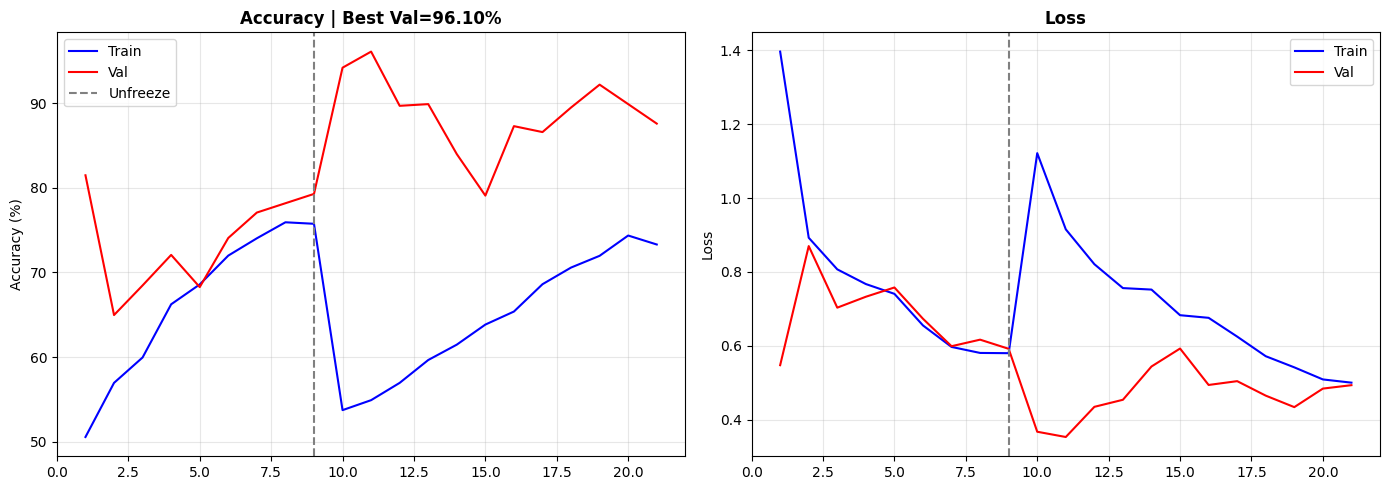

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step

  Accuracy  : 96.10%
  F1 (macro): 0.5365
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       978
    Abnormal       0.09      0.10      0.09        21

    accuracy                           0.96       999
   macro avg       0.54      0.54      0.54       999
weighted avg       0.96      0.96      0.96       999



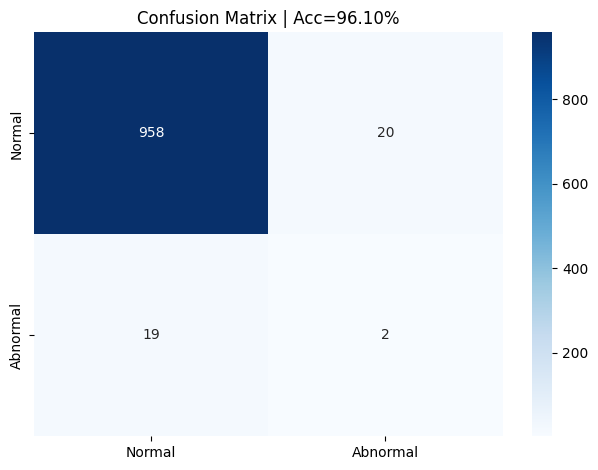

✅ Saved — mobilenetv2_test_probs.npy + lbl_test.npy


In [10]:
# Cell 6 — Evaluate + curves + confusion matrix + save for ensemble
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

acc      = h1.history['accuracy']     + h2.history['accuracy']
val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss     = h1.history['loss']         + h2.history['loss']
val_loss = h1.history['val_loss']     + h2.history['val_loss']
p1_end   = len(h1.history['accuracy'])
ep       = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, [a*100 for a in acc],    'b-', label='Train')
ax1.plot(ep, [a*100 for a in val_acc],'r-', label='Val')
ax1.axvline(p1_end, color='gray', linestyle='--', label='Unfreeze')
ax1.set_title(f'Accuracy | Best Val={max(val_acc)*100:.2f}%', fontweight='bold')
ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, loss,     'b-', label='Train')
ax2.plot(ep, val_loss, 'r-', label='Val')
ax2.axvline(p1_end, color='gray', linestyle='--')
ax2.set_title('Loss', fontweight='bold')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mobilenetv2_curves.png', dpi=150)
plt.show()

probs = model.predict(test_ds, verbose=1)
preds = np.argmax(probs, axis=1)
true  = np.array(lbl_test)

acc_t = accuracy_score(true, preds) * 100
f1    = f1_score(true, preds, average='macro', zero_division=0)
print('\n' + '='*50)
print(f'  Accuracy  : {acc_t:.2f}%')
print(f'  F1 (macro): {f1:.4f}')
print('='*50)
print(classification_report(true, preds, target_names=['Normal', 'Abnormal'], zero_division=0))

cm = confusion_matrix(true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title(f'Confusion Matrix | Acc={acc_t:.2f}%')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mobilenetv2_confusion.png', dpi=150)
plt.show()

np.save(f'{OUTPUT_DIR}/mobilenetv2_test_probs.npy', probs)
np.save(f'{OUTPUT_DIR}/lbl_test.npy', true)
print('✅ Saved — mobilenetv2_test_probs.npy + lbl_test.npy')

## ✅ MobileNetV2 Complete
**Download from Output tab:**
- `mobilenetv2_best.keras` — trained model weights
- `mobilenetv2_test_probs.npy` — test set probability outputs (needed for ensemble)
- `lbl_test.npy` — true test labels (needed for ensemble)
- `mobilenetv2_curves.png` — training curves
- `mobilenetv2_confusion.png` — confusion matrix